# Wine Quality Dataset

## Data Set: Wine Quality Data Set

### Source
The dataset was obtained from the **UCI Machine Learning Repository**.

### Authors / Creators
- Paulo Cortez  
- António Cerdeira  
- Fernando Almeida  
- Telmo Matos  
- José Reis  

(University of Minho, Portugal)

### Original Reference
Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J.  
*Modeling wine preferences by data mining from physicochemical properties.*  
Decision Support Systems, 47(4), 547–553, 2009.

---

## Dataset Description

The Wine Quality dataset contains physicochemical measurements of Portuguese **Vinho Verde** wines, aimed at predicting wine quality as assessed by human experts.

Two separate datasets are provided:
- **Wine Quality – Red wine**
- **Wine Quality – White wine**

Although red and white wines differ in composition, both datasets share the same set of input variables and were generated using the same experimental protocol.

---

## Input Features (Physicochemical Variables)

Each wine sample is described by **11 numerical physicochemical attributes**:

1. Fixed acidity  
2. Volatile acidity  
3. Citric acid  
4. Residual sugar  
5. Chlorides  
6. Free sulfur dioxide  
7. Total sulfur dioxide  
8. Density  
9. pH  
10. Sulphates  
11. Alcohol  

All input variables are continuous and require no categorical encoding.

---

## Target Variable

- **Quality**:  
  An integer score ranging typically from **3 to 9**, representing the sensory quality of the wine as evaluated by experts.

In this study, the `quality` variable is used in two different ways:
- **Classification task**: quality treated as discrete classes.
- **Regression task**: quality treated as a continuous numerical variable.

---

## Dataset Characteristics

- Total instances:
  - Red wine: 1,599 samples
  - White wine: 4,898 samples
- No missing values
- Strong class imbalance in the quality scores

---

## Motivation for Use

This dataset is widely used as a benchmark for:
- Multiclass classification
- Regression modeling
- Feature importance analysis
- Comparison between classical machine learning models and neural networks

### Data File Download
The datasets were downloaded from the UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/186/wine+quality

# Classical Machine Learning Models and Artificial Neural Networks

## Description

### Data Loading
Two datasets are used:
- `winequality-red.csv`
- `winequality-white.csv`

For both datasets:
- The first **11 columns** correspond to physicochemical variables (features).
- The target variable is **`quality`**, representing wine quality scores.

The target variable is treated in two different ways:
- **Classification**: `quality` is considered as discrete classes.
- **Regression**: `quality` is considered as a continuous numerical variable.

---

## Data Preprocessing

- Missing values are checked (no imputation is required if none are found).
- Exploratory Data Analysis (EDA) is performed to analyze:
  - Feature distributions
  - Correlations between variables
  - Class imbalance
- No categorical encoding is required, since all input variables are numerical.

---

## Feature Scaling

- **RobustScaler** is applied to the input features.
- This scaler uses the **median** and **interquartile range (IQR)**, making it less sensitive to outliers than standard normalization based on mean and standard deviation.
- Feature scaling is implemented using **scikit-learn Pipelines** to prevent data leakage during cross-validation.

---

## Class Imbalance Handling (Classification)

The dataset exhibits significant class imbalance.

To address this issue:
- `class_weight` is used for:
  - ANN
  - Random Forest
  - Extra Trees
  - Support Vector Machines (SVC)
- `sample_weight` is optionally used for **XGBoost** as an advanced imbalance-handling strategy.

Model selection and evaluation are based on **F1-macro**, which provides equal importance to all classes and is more appropriate than accuracy for imbalanced datasets.

---

## Modeling Approaches

Two categories of models are implemented:

### 1. Classical Machine Learning Models

The following models are implemented for both **classification** and **regression** tasks:

- Random Forest
- XGBoost
- Extra Trees
- Support Vector Machines:
  - **SVC** for classification
  - **SVR** for regression

For SVM-based models:
- Feature scaling is mandatory.
- Pipelines combining **RobustScaler + SVM/SVR** are used.

---

## Hyperparameter Optimization

- **RandomizedSearchCV** is used for hyperparameter tuning.
- Separate search objects are defined for:
  - Classification models
  - Regression models
- The same hyperparameter ranges are reused when appropriate.
- **3-fold cross-validation** (`cv=3`) is applied consistently across all models.

---

### 2. Artificial Neural Networks (ANN)

#### ANN Classifier
- Architecture:
  - Two hidden layers
  - ReLU activation for hidden layers
  - Softmax activation for the output layer
- Loss function:
  - `sparse_categorical_crossentropy`
- Optimizer:
  - Adam
- Regularization:
  - L2 regularization
  - Dropout layers
- Training strategy:
  - **EarlyStopping** is used instead of a fixed number of epochs to prevent overfitting.

#### ANN Regressor
- Same base architecture as the ANN Classifier.
- Output layer:
  - Single neuron with **linear activation**.
- Loss function:
  - Mean Squared Error (MSE).

---

## Evaluation Metrics

### Classification
- **Primary metric**:
  - F1-macro
- **Secondary metrics**:
  - Accuracy
  - Confusion matrix
  - Classification report

### Regression
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Coefficient of determination (R²)

---

## Final Objective

The main objectives of this study are:
- To compare **classical machine learning models** with **Artificial Neural Networks**.
- To determine whether wine quality is better modeled as:
  - A **classification problem** (discrete quality classes), or
  - A **regression problem** (continuous quality score).
- To select the most robust and generalizable model based on **test set performance**.

### Data Loading

In [1]:
# Instalación de Tensorflow
# pip install tensorflow

# Parte 1 - Preprocesamiento de Datos

# Importando las librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
def load_wine_dataset(red_path, white_path):
    """Carga los datasets de vino tinto y blanco y los une en un solo DataFrame."""
    red = pd.read_csv(red_path, sep=";")
    white = pd.read_csv(white_path, sep=";")
    
    # Unirlos uno debajo del otro
    dataset = pd.concat([red, white], axis=0, ignore_index=True)  
    return dataset

In [3]:

def encode_quality_7classes(y):
    """
    Reindexa las clases originales de calidad del vino:
    [3,4,5,6,7,8,9] → [0,1,2,3,4,5,6]
    
    Parámetros:
    y : pandas Series o array-like
        Variable objetivo original (quality)

    Retorna:
    y_encoded : pandas Series
        Etiquetas reindexadas aptas para ANN / XGBoost
    """
    mapping = {
        3: 0,
        4: 1,
        5: 2,
        6: 3,
        7: 4,
        8: 5,
        9: 6
    }
    return y.map(mapping)

In [4]:
# Construcción de una función que realice el particionado completo con estratificación
def train_val_test_split(df, rstate=42, shuffle=True, stratify_col=None):
    """
    Divide el DataFrame en train (80%), test (20%)
    usando muestreo estratificado segun la columna objetivo.
    Parametros:
    - df: DataFrame completo
    - target_col: nombre de la columna objetivo (ej: "quality")
    - rstate: semilla para reproducibilidad
    - shuffle: mezclar o no los datos
    """
    # Primera división: train (80%) y temp (20%)
    # Estratificación segun objetivo
    strat = df[stratify_col] if stratify_col else None
    train_set, test_set = train_test_split(
        df, test_size=0.2, random_state=rstate, shuffle=shuffle, stratify=strat
    )
    """
    # Segunda división: val (10%) y test (10%)
    strat = temp_set[stratify_col] if stratify_col else None
    val_set, test_set = train_test_split(
        temp_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat
    )
    """
    return train_set, test_set



In [5]:
# Cargar dataset
df = load_wine_dataset("winequality-red.csv", "winequality-white.csv")
#dataset['quality'] = dataset['quality'].apply(map_quality_to_classes)
# Verificar nulos
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
# Mostrar información básica sobre el conjunto de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [7]:
from scipy import stats
# DataFrame sin quality para z-score
df_num = df.drop(columns=['quality'])
# Z-score (numpy array) SOLO sobre variables químicas o independientes
z_array = np.abs(stats.zscore(df_num))
# 🔑 Convertir a DataFrame para poder usar nombres de columnas
z = pd.DataFrame(z_array, columns=df_num.columns, index=df.index)

threshold = 3

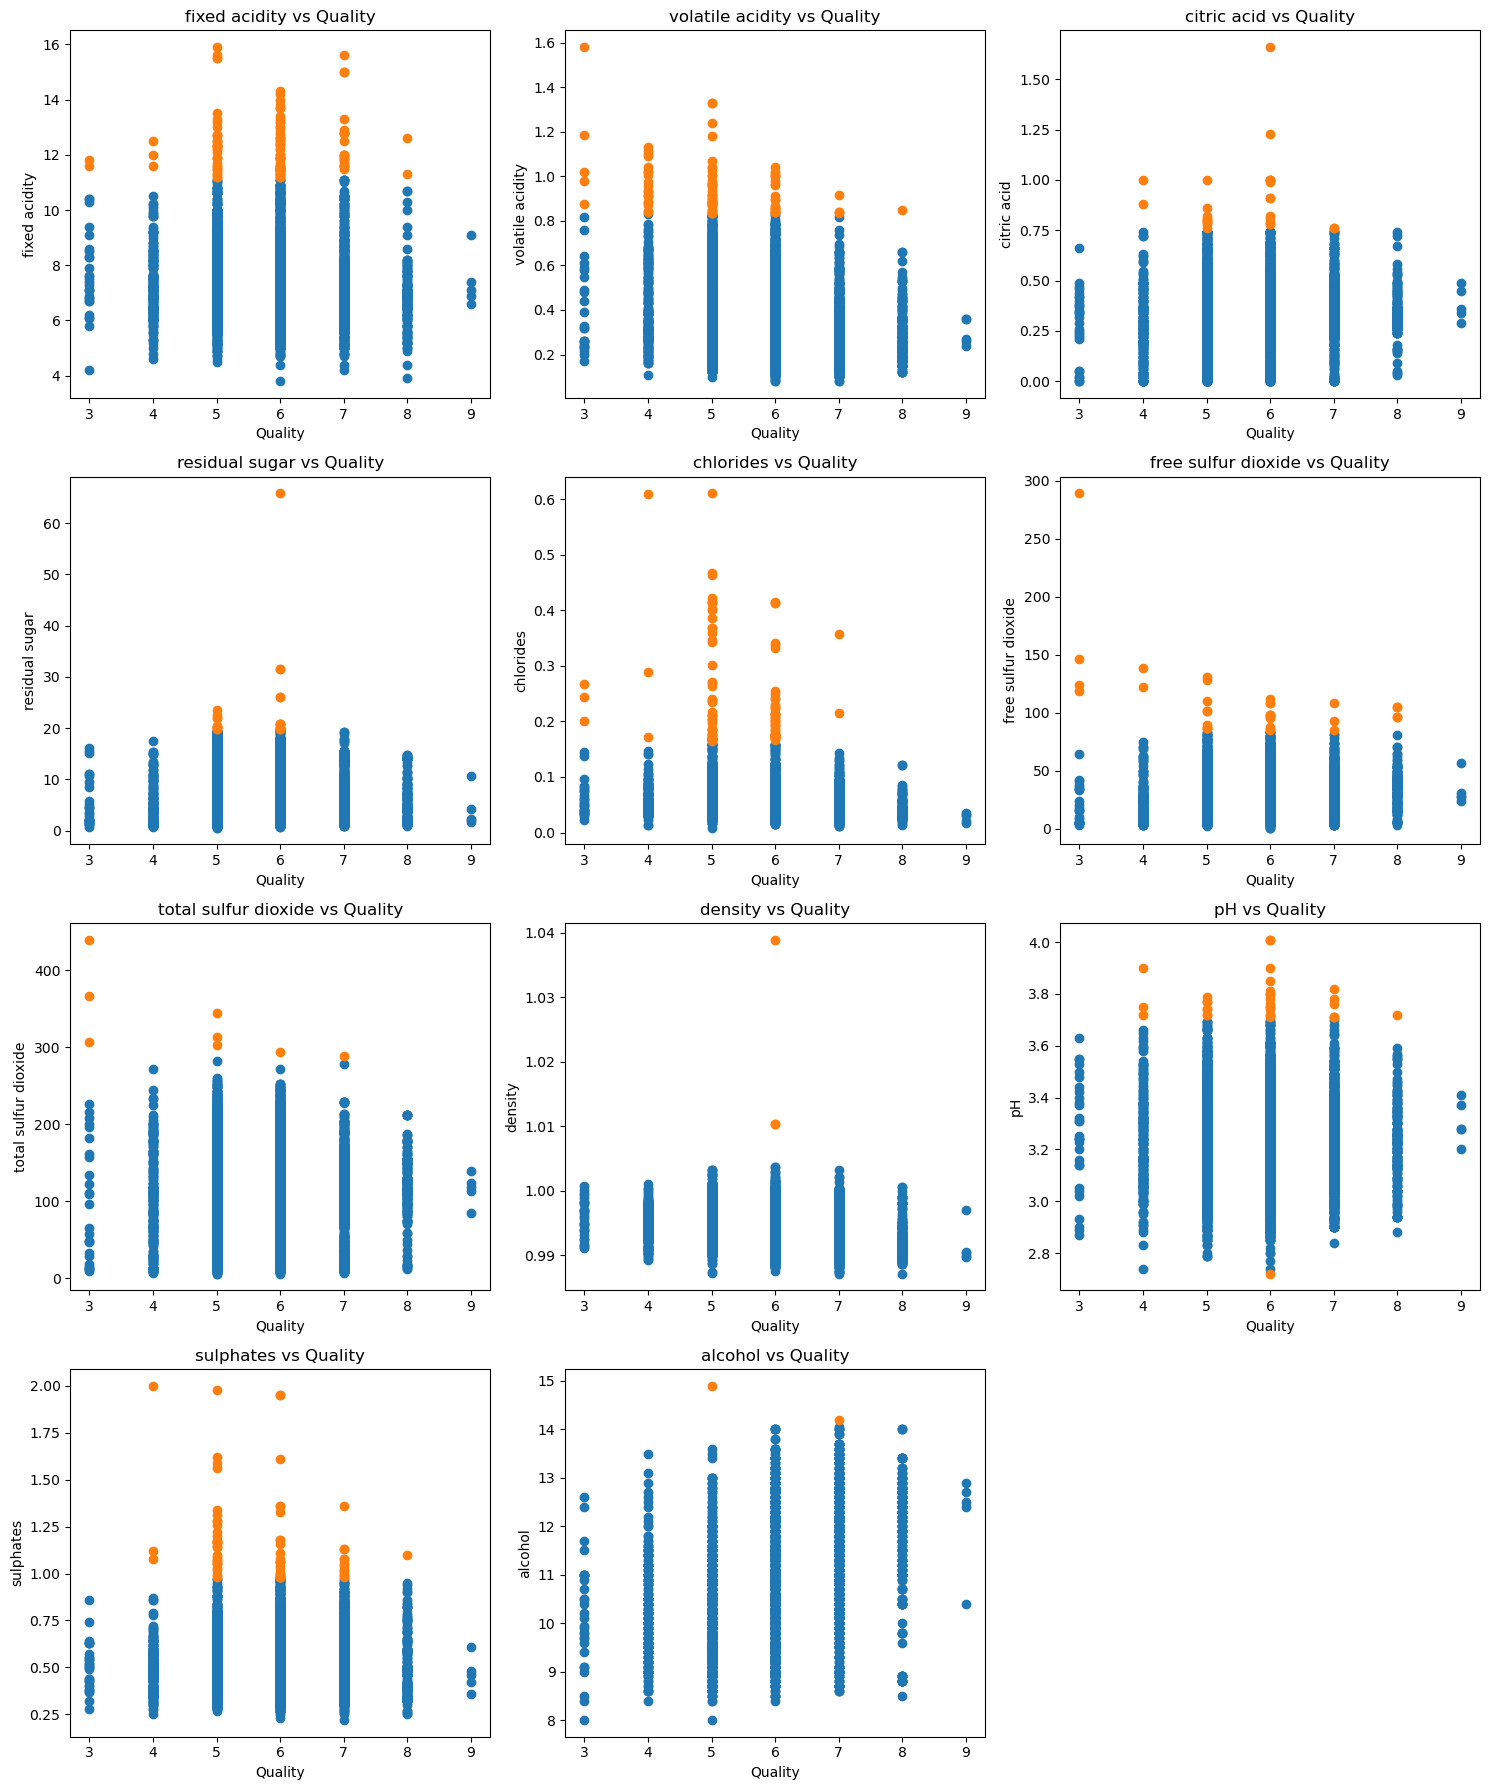

In [8]:
import matplotlib.pyplot as plt

# Variables a graficar (todas menos quality)
features = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH',
    'sulphates', 'alcohol'
]
# Crear subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
axes = axes.flatten()

for i, feature in enumerate(features):
    # Máscara de outliers SOLO para esta variable
    outliers = z[feature] > threshold

    # Puntos normales
    axes[i].scatter(
        df.loc[~outliers, 'quality'],
        df.loc[~outliers, feature],
        label='Normal'
    )

    # Puntos outliers
    axes[i].scatter(
        df.loc[outliers, 'quality'],
        df.loc[outliers, feature],
        label='Outlier'
    )

    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'{feature} vs Quality')

# Eliminar subplots vacíos
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [9]:
# eliminar outliers basada en puntuación Z, se usa z > 3 porque valores a más de 3 desviaciones estándar de la media son estadísticamente muy raros y se consideran valores atípicos.
# Crear una copia
df_o = df[(z < threshold).all(axis=1)].copy()

In [10]:
print("Antiguo Shape: ", df.shape)
print("Nuevo Shape: ", df_o.shape)

Antiguo Shape:  (6497, 12)
Nuevo Shape:  (6009, 12)


### 2. Visualización del conjunto de datos

In [11]:
df_o.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5


In [12]:
# Análisis exploratorio de datos
# Estadisticas descriptivas
# Mostrar información estadística sobre el conjunto de datos
df_o.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000,6009.000000
mean,7.094400,0.326473,0.312827,5.502355,0.051594,30.711017,118.006490,0.994501,3.218476,0.519333,10.508584,5.840073
std,1.049439,0.146075,0.133340,4.650097,0.021046,16.371290,54.383357,0.002864,0.154581,0.127270,1.196047,0.863842
min,3.900000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.740000,0.220000,8.000000,3.000000
25%,6.400000,0.220000,0.250000,1.800000,0.037000,18.000000,84.000000,0.992160,3.110000,0.430000,9.500000,5.000000
50%,6.900000,0.290000,0.310000,3.200000,0.046000,29.000000,120.000000,0.994700,3.210000,0.500000,10.300000,6.000000
75%,7.600000,0.390000,0.380000,8.200000,0.060000,42.000000,156.000000,0.996800,3.320000,0.590000,11.300000,6.000000
max,11.100000,0.830000,0.740000,19.500000,0.161000,83.000000,282.000000,1.002600,3.700000,0.970000,14.050000,9.000000


In [13]:
# Cuántos datos hay de cada clase
class_counts = df_o["quality"].value_counts().sort_index()
print(class_counts)

quality
3      15
4     184
5    1958
6    2636
7    1027
8     184
9       5
Name: count, dtype: int64


In [14]:
# Mostrar la correlación entre los atributos del conjunto de datos
corr_matrix = df_o.corr()
print(corr_matrix)

corr_with_quality = corr_matrix["quality"].sort_values(ascending=False)


                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.203798     0.242975   
volatile acidity           0.203798          1.000000    -0.430316   
citric acid                0.242975         -0.430316     1.000000   
residual sugar            -0.090725         -0.197475     0.164791   
chlorides                  0.364613          0.495773    -0.136810   
free sulfur dioxide       -0.250660         -0.346247     0.187595   
total sulfur dioxide      -0.273783         -0.404227     0.258514   
density                    0.406107          0.247667     0.040590   
pH                        -0.222960          0.263053    -0.293374   
sulphates                  0.232163          0.225029    -0.017991   
alcohol                   -0.103136         -0.039888    -0.000392   
quality                   -0.084995         -0.239274     0.081279   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

In [15]:
# Quedarnos con las variables cuya correlación (en valor absoluto) sea mayor que 0.08
selected_features = corr_with_quality[abs(corr_with_quality) > 0.08]
# Quitamos la propia variable objetivo si aparece
selected_features = selected_features.drop("quality", errors="ignore")
# Imprimir variables y su correlación
print("Selected features with correlation to 'quality' > 0.08:\n", selected_features)
print("\nVariables seleccionadas:")
for feature, corr_value in selected_features.items():
    print(f"{feature}")

Selected features with correlation to 'quality' > 0.08:
 alcohol             0.451357
citric acid         0.081279
fixed acidity      -0.084995
volatile acidity   -0.239274
chlorides          -0.248220
density            -0.319725
Name: quality, dtype: float64

Variables seleccionadas:
alcohol
citric acid
fixed acidity
volatile acidity
chlorides
density


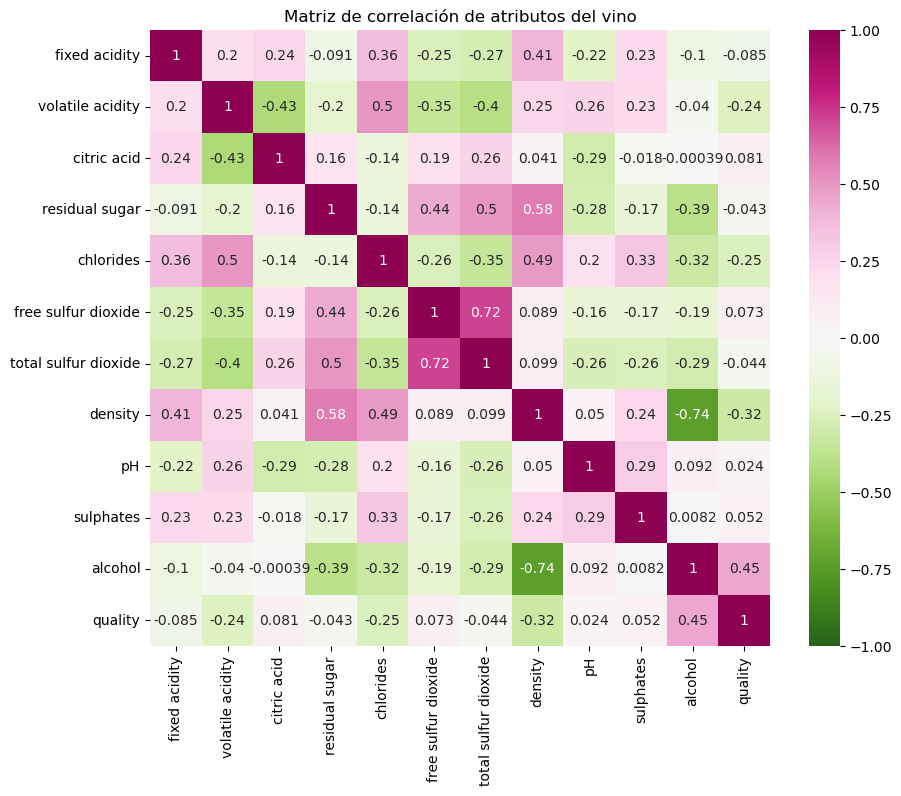

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_o.corr(), vmin=-1, vmax=1, annot=True, cmap="PiYG_r")
plt.title("Matriz de correlación de atributos del vino")
plt.show()


### Preparación del conjunto de datos:

In [17]:
#re-codifica completamente la columna quality
df_o['quality'] = encode_quality_7classes(df_o['quality'])
# Dividiendo el conjunto de datos en conjunto de entrenamiento y conjunto de prueba
train_set, test_set = train_val_test_split(df_o, stratify_col="quality")

# Separar X e y en cada conjunto
# Train
X_train = train_set.drop("quality", axis=1)
y_train = train_set["quality"]

print(f"Tamaño original de X_train: {X_train.shape}")
print(f"Distribución original de clases en y_train: {Counter(y_train)}")

# Test
X_test = test_set.drop("quality", axis=1)
y_test = test_set["quality"]

print(f"Tamaño original de X_test: {X_test.shape}")
print(f"Distribución original de clases en y_test: {Counter(y_test)}")

print("Clases finales:", np.unique(y_train))

Tamaño original de X_train: (4807, 11)
Distribución original de clases en y_train: Counter({3: 2109, 2: 1566, 4: 822, 5: 147, 1: 147, 0: 12, 6: 4})
Tamaño original de X_test: (1202, 11)
Distribución original de clases en y_test: Counter({3: 527, 2: 392, 4: 205, 5: 37, 1: 37, 0: 3, 6: 1})
Clases finales: [0 1 2 3 4 5 6]


In [18]:
# =========================================
#  Variables medibles
# =========================================
measurable_features = [
    'residual sugar', 'density', 'pH', 'alcohol'
]
# measurable_features = ['alcohol', 'pH', 'density', 'residual sugar']
# Reducir X_train, X_val, X_test a estas columnas
X_train = X_train[measurable_features]
X_test = X_test[measurable_features]

### Normalización y estandarización

In [19]:
# Normalización y estandarización
from sklearn.preprocessing import RobustScaler

# Creamos el escalador robusto (usa mediana e IQR, no media y desviación típica)
sc = RobustScaler()

# Ajustamos SOLO con el conjunto de entrenamiento
# (para no "filtrar" información del test)
X_train = sc.fit_transform(X_train)

# Aplicamos la MISMA transformación al conjunto de validación y test
X_test = sc.transform(X_test)

In [20]:
# ============================================================
# COMMON IMPORTS AND GLOBAL UTILITIES
# ============================================================

# Numerical operations
import numpy as np

# Model selection and pipelines
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# Feature scaling (robust to outliers)
from sklearn.preprocessing import RobustScaler

# Metrics for classification and regression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

In [21]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def print_best_model(search, model_name, metric_name, invert_score=False):
    """
    Print the best hyperparameters and the best cross-validation score
    obtained during RandomizedSearchCV.
    
    Parameters
    ----------
    search : RandomizedSearchCV
        Fitted search object.
    model_name : str
        Name of the model (for reporting purposes).
    metric_name : str
        Name of the metric being optimized.
    invert_score : bool
        Set to True when sklearn uses a negative metric (e.g., RMSE).
    """
    print(f"\nBest parameters ({model_name}):")
    print(search.best_params_)

    score = -search.best_score_ if invert_score else search.best_score_
    print(f"Best {metric_name} (CV):", score)


def evaluate_classifier(model, X_test, y_test, model_name):
    """
    Evaluate a classification model on the test set.
    Uses metrics suitable for imbalanced multiclass problems.
    """
    y_pred = model.predict(X_test)

    print(f"\n=== {model_name} - Classification (Test) ===")
    print("Accuracy:", model.score(X_test, y_test))
    print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


def evaluate_regressor(model, X_test, y_test, model_name):
    """
    Evaluate a regression model on the test set
    using standard regression metrics.
    Compatible with older scikit-learn versions.
    """
    y_pred = model.predict(X_test)

    # Compute RMSE manually for compatibility
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {model_name} - Regression (Test) ===")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

In [22]:
def plot_feature_importance(
    model,
    feature_names,
    model_name,
    task_type="classification",
    top_n=None
):

    # -------------------------------------------------
    # Check that the model provides feature importance
    # -------------------------------------------------
    if not hasattr(model, "feature_importances_"):
        raise ValueError(
            f"The model {model_name} does not provide feature_importances_."
        )

    # Extract feature importances
    importances = model.feature_importances_

    # Create pandas Series with feature names
    feature_imp = pd.Series(
        importances,
        index=feature_names
    ).sort_values(ascending=False)

    # Optionally select only top N features
    if top_n is not None:
        feature_imp = feature_imp.head(top_n)

    # Print importance values
    print(f"\nFeature Importance - {model_name} ({task_type}):")
    print(feature_imp)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x=feature_imp.values,
        y=feature_imp.index
    )
    plt.title(f"Feature Importance - {model_name} ({task_type})")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

### CLASSIFICATION MODELS

### 🌳RANDOM FOREST — CLASSIFICATION 

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Define the base Random Forest classifier
# class_weight="balanced" is used to handle class imbalance
rf_clf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Define the hyperparameter search space
rf_clf_param_dist = {
    "n_estimators": [300, 500, 800, 1200],     # Number of trees in the forest
    "max_depth": [None, 10, 12, 15],         # Maximum tree depth
    "min_samples_split": [5, 10, 20],    # Minimum samples to split a node
    "min_samples_leaf": [2, 5, 10],      # Minimum samples in leaf nodes
    "max_features": ["sqrt", "log2"]     # Feature subsampling strategy
}

# Randomized search with F1-macro as scoring metric
rf_clf_search = RandomizedSearchCV(
    rf_clf,
    rf_clf_param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_clf_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    rf_clf_search,
    "Random Forest - Classification",
    "F1-macro"
)

# Extract the best trained model
best_rf_clf = rf_clf_search.best_estimator_

# Evaluate on the test set
evaluate_classifier(best_rf_clf, X_test, y_test, "Random Forest")


Best parameters (Random Forest - Classification):
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
Best F1-macro (CV): 0.3210203906031482

=== Random Forest - Classification (Test) ===
Accuracy: 0.5956738768718802
F1 Macro: 0.3574797055261432

Confusion Matrix:
[[  0   0   1   0   2   0   0]
 [  0   5  15  12   5   0   0]
 [  1   8 271  94  17   1   0]
 [  0   1 115 309  94   8   0]
 [  0   2   7  79 112   5   0]
 [  0   0   0   4  14  19   0]
 [  0   0   0   0   0   1   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.31      0.14      0.19        37
           2       0.66      0.69      0.68       392
           3       0.62      0.59      0.60       527
           4       0.46      0.55      0.50       205
           5       0.56      0.51      0.54        37
           6       0.00      0.00      0.00         1




Feature Importance - Random Forest (classification):
density           0.290155
alcohol           0.252300
residual sugar    0.245256
pH                0.212288
dtype: float64


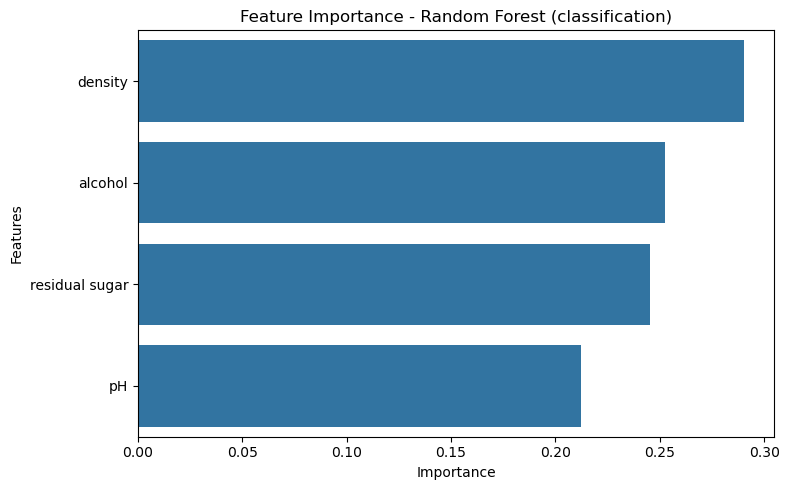

In [24]:
plot_feature_importance(
    model=best_rf_clf,
    feature_names=measurable_features,
    model_name="Random Forest",
    task_type="classification",
    top_n=10   # optional
)

### 🌲 Extra Trees — Classification

In [25]:
from sklearn.ensemble import ExtraTreesClassifier

# -------------------------------------------------
# Extra Trees Classifier
# -------------------------------------------------
# Extra Trees increases randomness compared to
# Random Forest by selecting split thresholds
# completely at random. This often reduces variance
# and improves generalization on tabular datasets.
# -------------------------------------------------

etc_clf = ExtraTreesClassifier(
    class_weight="balanced",   # Handle class imbalance
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# Hyperparameter search space
# -------------------------------------------------

etc_clf_param_dist = {
    "n_estimators": [400, 600, 800, 2000],      # Number of trees
    "max_depth": [None, 10, 14, 15],          # Maximum tree depth
    "min_samples_split": [5, 10, 20],     # Min samples to split a node
    "min_samples_leaf": [2, 5, 10],       # Min samples per leaf
    "max_features": ["sqrt", "log2"]      # Feature subsampling
}

# -------------------------------------------------
# RandomizedSearchCV for Extra Trees (classification)
# -------------------------------------------------

etc_clf_search = RandomizedSearchCV(
    estimator=etc_clf,
    param_distributions=etc_clf_param_dist,
    n_iter=30,
    scoring="f1_macro",    # Robust metric for imbalanced classes
    cv=3,
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# Train the model
# -------------------------------------------------

etc_clf_search.fit(X_train, y_train)

# -------------------------------------------------
# Print best hyperparameters and CV score
# -------------------------------------------------

print_best_model(
    etc_clf_search,
    "Extra Trees - Classification",
    "F1-macro"
)

# -------------------------------------------------
# Extract best trained model
# -------------------------------------------------

best_etc_clf = etc_clf_search.best_estimator_

# -------------------------------------------------
# Evaluate on the test set
# -------------------------------------------------

evaluate_classifier(best_etc_clf, X_test, y_test, "Extra Trees")


Best parameters (Extra Trees - Classification):
{'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
Best F1-macro (CV): 0.3113613698778169

=== Extra Trees - Classification (Test) ===
Accuracy: 0.5757071547420965
F1 Macro: 0.3420987585254548

Confusion Matrix:
[[  0   1   0   0   2   0   0]
 [  0   7  14   9   7   0   0]
 [  2  21 275  67  25   1   1]
 [  1  16 125 259 107  18   1]
 [  0   5   6  53 131  10   0]
 [  0   1   0   2  14  20   0]
 [  0   0   0   0   0   1   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.14      0.19      0.16        37
           2       0.65      0.70      0.68       392
           3       0.66      0.49      0.56       527
           4       0.46      0.64      0.53       205
           5       0.40      0.54      0.46        37
           6       0.00      0.00      0.00         1

    


Feature Importance - Extra Trees (classification):
alcohol           0.309265
residual sugar    0.243530
density           0.238732
pH                0.208472
dtype: float64


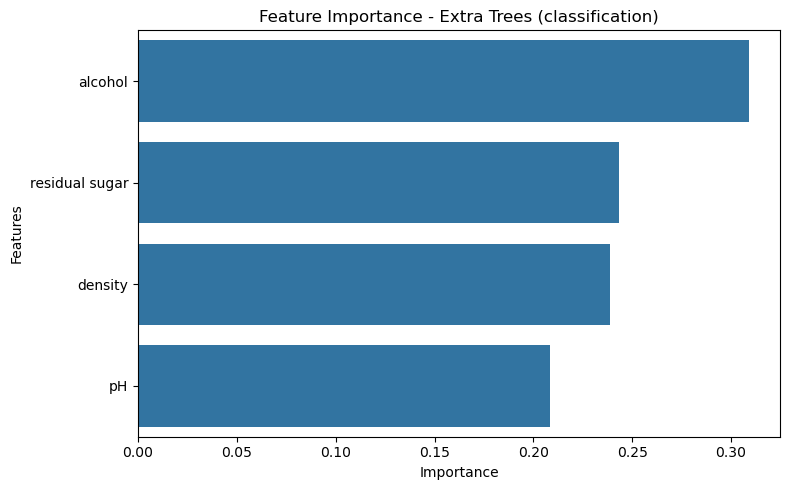

In [26]:
plot_feature_importance(
    model=best_etc_clf,
    feature_names=measurable_features,
    model_name="Extra Trees",
    task_type="classification",
    top_n=10
)

## 🚀 XGBoost — Classification

In [27]:
import xgboost as xgb

# Determine the number of classes automatically
num_classes = len(np.unique(y_train))

# Define the base XGBoost classifier for multiclass problems
xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",   # Multiclass probability output
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
xgb_clf_param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5, 10]
}

# Randomized hyperparameter optimization
xgb_clf_search = RandomizedSearchCV(
    xgb_clf,
    xgb_clf_param_dist,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_clf_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    xgb_clf_search,
    "XGBoost - Classification",
    "F1-macro"
)

# Extract the best trained model
best_xgb_clf = xgb_clf_search.best_estimator_

# Evaluate on the test set
evaluate_classifier(best_xgb_clf, X_test, y_test, "XGBoost")


Best parameters (XGBoost - Classification):
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1-macro (CV): 0.3256773826099071

=== XGBoost - Classification (Test) ===
Accuracy: 0.6464226289517471
F1 Macro: 0.38103166751733725

Confusion Matrix:
[[  0   0   0   2   1   0   0]
 [  0   3  14  17   3   0   0]
 [  0   4 263 118   7   0   0]
 [  0   0  86 385  54   2   0]
 [  0   3   8  84 107   3   0]
 [  0   0   0   8  10  19   0]
 [  0   0   0   1   0   0   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.30      0.08      0.13        37
           2       0.71      0.67      0.69       392
           3       0.63      0.73      0.67       527
           4       0.59      0.52      0.55       205
           5       0.79      0.51      0.62        37
           6       0.00      0.00      0.00       


Feature Importance - XGBoost (classification):
alcohol           0.307507
density           0.240534
residual sugar    0.234491
pH                0.217467
dtype: float32


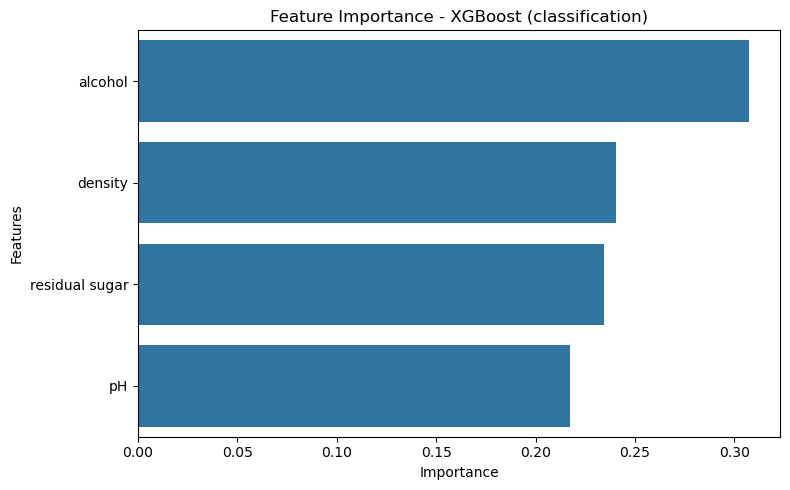

In [28]:
plot_feature_importance(
    model=best_xgb_clf,
    feature_names=measurable_features,
    model_name="XGBoost",
    task_type="classification",
    top_n=10
)

## ⚙️ Support Vector Machine — Classification

In [29]:
from sklearn.svm import SVC

# SVM is sensitive to feature scale, so we use a pipeline with RobustScaler
svc_pipeline = Pipeline([
    ("scaler", RobustScaler()),      # Robust scaling to reduce effect of outliers
    ("svc", SVC(
        class_weight="balanced",     # Handle class imbalance
        random_state=42
    ))
])

# Hyperparameter search space for SVM
svc_param_dist = {
    "svc__C": np.logspace(-2, 2, 8),           # Regularization strength
    "svc__gamma": ["scale", "auto"] + list(np.logspace(-3, -1, 4)),
    "svc__kernel": ["rbf"]                     # RBF kernel works best for tabular data
}

# Randomized search for SVM
svc_search = RandomizedSearchCV(
    svc_pipeline,
    svc_param_dist,
    n_iter=25,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
svc_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    svc_search,
    "SVM - Classification",
    "F1-macro"
)

# Extract the best trained model
best_svc = svc_search.best_estimator_

# Evaluate on the test set
evaluate_classifier(best_svc, X_test, y_test, "SVM")


Best parameters (SVM - Classification):
{'svc__kernel': 'rbf', 'svc__gamma': 'auto', 'svc__C': np.float64(100.0)}
Best F1-macro (CV): 0.19748768483882403

=== SVM - Classification (Test) ===
Accuracy: 0.3178036605657238
F1 Macro: 0.19824235049702899

Confusion Matrix:
[[  0   1   0   0   0   2   0]
 [  2  13  12   2   6   2   0]
 [ 24 101 191  24  33  19   0]
 [ 18  98 141  75 116  71   8]
 [  3  34   9  21  84  54   0]
 [  1   0   0   2  13  19   2]
 [  0   0   0   0   0   1   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.05      0.35      0.09        37
           2       0.54      0.49      0.51       392
           3       0.60      0.14      0.23       527
           4       0.33      0.41      0.37       205
           5       0.11      0.51      0.19        37
           6       0.00      0.00      0.00         1

    accuracy                           0.32      1202


## Entrenamiento Random Forest para Clasificación

## REGRESSION MODELS

### 🌳 Random Forest — Regression

In [30]:
from sklearn.ensemble import RandomForestRegressor

# Define the base Random Forest regressor
rf_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
rf_reg_param_dist = {
    "n_estimators": [300, 500, 800, 2000],
    "max_depth": [None, 10, 14, 15],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# Randomized search using RMSE as optimization metric
rf_reg_search = RandomizedSearchCV(
    rf_reg,
    rf_reg_param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_reg_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    rf_reg_search,
    "Random Forest - Regression",
    "RMSE",
    invert_score=True
)

# Extract the best trained model
best_rf_reg = rf_reg_search.best_estimator_

# Evaluate on the test set
evaluate_regressor(best_rf_reg, X_test, y_test, "Random Forest")


Best parameters (Random Forest - Regression):
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
Best RMSE (CV): 0.6978976097847118

=== Random Forest - Regression (Test) ===
RMSE: 0.6743674604069336
MAE: 0.5134835970502984
R2: 0.3912820429197478



Feature Importance - Random Forest (regression):
alcohol           0.331977
density           0.273503
residual sugar    0.206987
pH                0.187534
dtype: float64


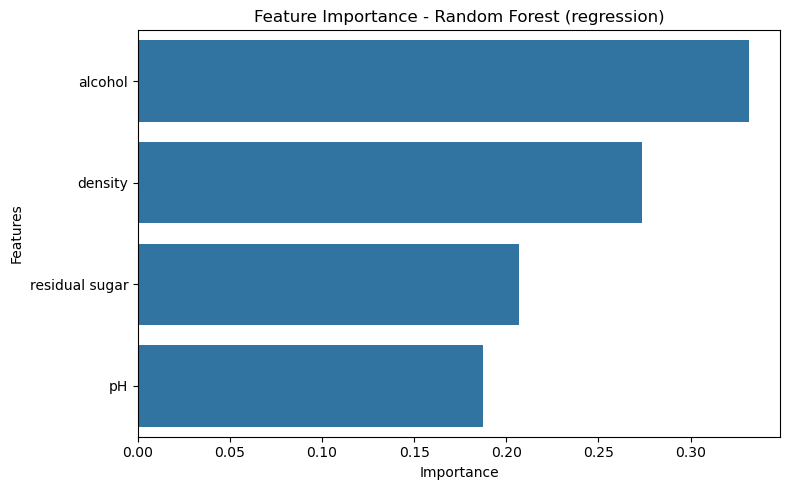

In [31]:
plot_feature_importance(
    model=best_rf_reg,
    feature_names=measurable_features,
    model_name="Random Forest",
    task_type="regression",
    top_n=10
)

### 🌲 Extra Trees — Regression

In [32]:
from sklearn.ensemble import ExtraTreesRegressor

# -------------------------------------------------
# Extra Trees Regressor
# -------------------------------------------------
# The regressor version follows the same principle
# as the classifier, but predicts continuous values.
# -------------------------------------------------

etc_reg = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# Hyperparameter search space
# -------------------------------------------------

etc_reg_param_dist = {
    "n_estimators": [400, 600, 800],
    "max_depth": [None, 10, 15],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# -------------------------------------------------
# RandomizedSearchCV for Extra Trees (regression)
# -------------------------------------------------
# RMSE is used as the optimization metric.
# sklearn uses negative values for loss functions.
# -------------------------------------------------

etc_reg_search = RandomizedSearchCV(
    estimator=etc_reg,
    param_distributions=etc_reg_param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# Train the model
# -------------------------------------------------

etc_reg_search.fit(X_train, y_train)

# -------------------------------------------------
# Print best hyperparameters and CV score
# -------------------------------------------------

print_best_model(
    etc_reg_search,
    "Extra Trees - Regression",
    "RMSE",
    invert_score=True
)

# -------------------------------------------------
# Extract best trained model
# -------------------------------------------------

best_etc_reg = etc_reg_search.best_estimator_

# -------------------------------------------------
# Evaluate on the test set
# -------------------------------------------------

evaluate_regressor(best_etc_reg, X_test, y_test, "Extra Trees")


Best parameters (Extra Trees - Regression):
{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best RMSE (CV): 0.6951748957811744

=== Extra Trees - Regression (Test) ===
RMSE: 0.6696060656035253
MAE: 0.5121011106246642
R2: 0.399847446054326



Feature Importance - Extra Trees (regression):
alcohol           0.411828
density           0.243633
residual sugar    0.182194
pH                0.162344
dtype: float64


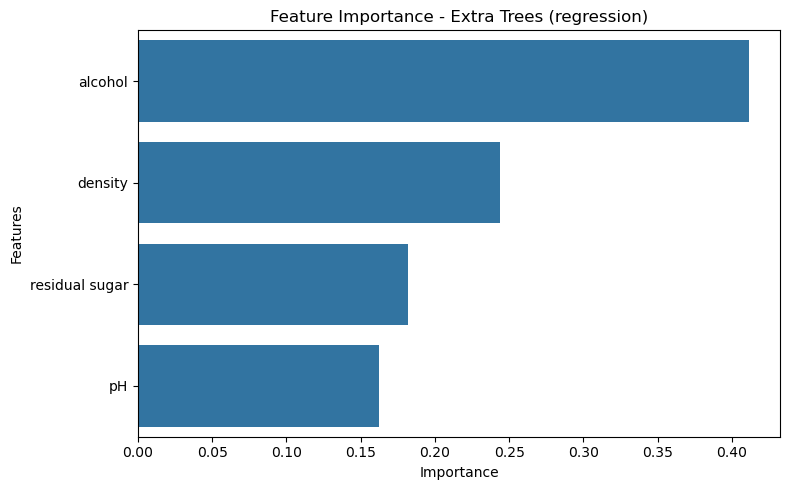

In [33]:
plot_feature_importance(
    model=best_etc_reg,
    feature_names=measurable_features,
    model_name="Extra Trees",
    task_type="regression",
    top_n=10
)

## 🚀 XGBoost — Regression

In [34]:
# Define the base XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
xgb_reg_param_dist = {
    "n_estimators": [300, 500, 700, 1200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Randomized search
xgb_reg_search = RandomizedSearchCV(
    xgb_reg,
    xgb_reg_param_dist,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_reg_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    xgb_reg_search,
    "XGBoost - Regression",
    "RMSE",
    invert_score=True
)

# Extract the best trained model
best_xgb_reg = xgb_reg_search.best_estimator_

# Evaluate on the test set
evaluate_regressor(best_xgb_reg, X_test, y_test, "XGBoost")


Best parameters (XGBoost - Regression):
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best RMSE (CV): 0.711377223332723

=== XGBoost - Regression (Test) ===
RMSE: 0.6830786153710992
MAE: 0.5180706977844238
R2: 0.3754541873931885



Feature Importance - XGBoost (regression):
alcohol           0.439621
residual sugar    0.202920
density           0.186164
pH                0.171295
dtype: float32


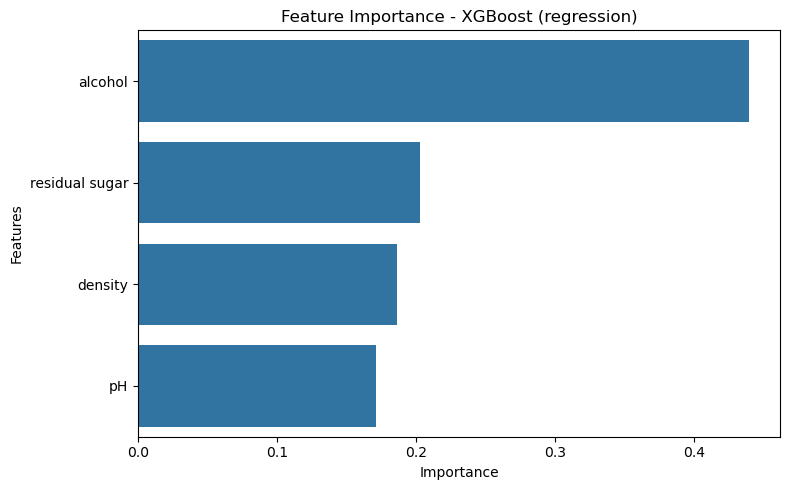

In [35]:
plot_feature_importance(
    model=best_xgb_reg,
    feature_names=measurable_features,
    model_name="XGBoost",
    task_type="regression",
    top_n=10
)

## ⚙️ Support Vector Regressor (SVR)

In [36]:
from sklearn.svm import SVR

# SVR also requires feature scaling
svr_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("svr", SVR())
])

# Hyperparameter search space
svr_param_dist = {
    "svr__C": np.logspace(-2, 2, 8),
    "svr__gamma": ["scale", "auto"] + list(np.logspace(-3, -1, 4)),
    "svr__epsilon": [0.01, 0.05, 0.1]
}

# Randomized search
svr_search = RandomizedSearchCV(
    svr_pipeline,
    svr_param_dist,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Train the model
svr_search.fit(X_train, y_train)

# Print best hyperparameters and CV score
print_best_model(
    svr_search,
    "SVR - Regression",
    "RMSE",
    invert_score=True
)

# Extract the best trained model
best_svr = svr_search.best_estimator_

# Evaluate on the test set
evaluate_regressor(best_svr, X_test, y_test, "SVR")


Best parameters (SVR - Regression):
{'svr__gamma': 'scale', 'svr__epsilon': 0.1, 'svr__C': np.float64(0.517947467923121)}
Best RMSE (CV): 0.7486983641979283

=== SVR - Regression (Test) ===
RMSE: 0.7499772705122661
MAE: 0.5745300438117222
R2: 0.24713154025560768


## Redes Neuronales con Clasificación

In [37]:
# ===============================
# 1. Imports and reproducibility
# ===============================
# Importando las librerías de Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [38]:
from sklearn.utils.class_weight import compute_class_weight
# =====================================
# 2. Compute class weights (imbalanced y)
# =====================================

# Get unique class labels
classes = np.unique(y_train)

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert to dictionary (required by Keras)
class_weights = dict(zip(classes, class_weights))

print("\nClass weights (interpretation):\n")

for cls, weight in class_weights.items():
    
    if weight > 100:
        label = "EXTREMELY RARE class (very high penalty)"
    elif weight > 20:
        label = "VERY RARE class (high penalty)"
    elif weight > 5:
        label = "RARE class"
    else:
        label = "COMMON class"
    
    print(f"Class {cls}: weight = {weight:.2f} → {label}")

# Number of output classes
num_classes = len(classes)


Class weights (interpretation):

Class 0: weight = 57.23 → VERY RARE class (high penalty)
Class 1: weight = 4.67 → COMMON class
Class 2: weight = 0.44 → COMMON class
Class 3: weight = 0.33 → COMMON class
Class 4: weight = 0.84 → COMMON class
Class 5: weight = 4.67 → COMMON class
Class 6: weight = 171.68 → EXTREMELY RARE class (very high penalty)


In [39]:
# ======================================
# 3. Define the ANN model building function
# ======================================

def build_classifier(optimizer="adam", neurons=16, dropout_rate=0.25):
    """
    Builds and compiles a regularized ANN for multiclass classification.
    
    Parameters:
    - optimizer: optimization algorithm ("adam" or "rmsprop")
    - neurons: number of neurons in the first hidden layer
    - dropout_rate: dropout rate for regularization
    """
    model = Sequential()
    
    model.add(Input(shape=(X_train.shape[1],)))
    
    model.add(Dense(
        units=neurons,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=l2(1e-4)
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(
        units=int(neurons * 0.75),
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=l2(1e-4)
    ))
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(num_classes, activation="softmax"))
    
    model.compile(
        optimizer=Adam() if optimizer == "adam" else RMSprop(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [40]:
from scikeras.wrappers import KerasClassifier
# ==================================================
# 4. Wrap the model with SciKeras + EarlyStopping
# ==================================================

classifier = KerasClassifier(
    model=build_classifier,
    optimizer="adam",
    neurons=16,
    dropout_rate=0.25,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    verbose=0,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ]
)

In [41]:
from sklearn.pipeline import Pipeline
# =====================================
# 5. Build the pipeline (Scaler + ANN)
# =====================================

# RobustScaler is used to reduce the influence of outliers
pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", classifier)
])

In [42]:
# =====================================
# 6. Hyperparameter search space
# =====================================

param_dist = {
    "clf__optimizer": ["adam", "rmsprop"],
    "clf__neurons": [12, 16, 24, 128],
    "clf__dropout_rate": [0.2, 0.3],
    "clf__batch_size": [32, 64]
}

In [43]:
from sklearn.model_selection import RandomizedSearchCV
# =====================================
# 7. RandomizedSearchCV
# =====================================

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",   # Suitable for imbalanced multiclass problems
    cv=3,
    random_state=42,
    n_jobs=-1
)

In [84]:
# ===============================
# Train ANN Classifier
# ===============================

# Train the ANN classifier using RandomizedSearchCV
random_search.fit(X_train, y_train, clf__validation_split=0.2)

# Print best hyperparameters and cross-validation performance
print_best_model(
    random_search,
    "ANN - Classification",
    "F1-macro"
)

# Extract the best trained ANN model
best_ann_clf = random_search.best_estimator_


Best parameters (ANN - Classification):
{'clf__optimizer': 'adam', 'clf__neurons': 128, 'clf__dropout_rate': 0.3, 'clf__batch_size': 64}
Best F1-macro (CV): 0.1348149196461447


In [45]:
# ===============================
# Evaluate ANN Classifier on Test Set
# ===============================

evaluate_classifier(
    best_ann_clf,
    X_test,
    y_test,
    "ANN"
)


=== ANN - Classification (Test) ===
Accuracy: 0.2853577371048253
F1 Macro: 0.1801644324998905

Confusion Matrix:
[[  0   1   0   0   0   2   0]
 [  4  10  14   2   2   5   0]
 [ 54  80 186  25  20  25   2]
 [ 41  92 134  71  75 100  14]
 [ 10  23   8  21  55  82   6]
 [  1   1   0   3  10  21   1]
 [  0   0   0   0   0   1   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.05      0.27      0.08        37
           2       0.54      0.47      0.51       392
           3       0.58      0.13      0.22       527
           4       0.34      0.27      0.30       205
           5       0.09      0.57      0.15        37
           6       0.00      0.00      0.00         1

    accuracy                           0.29      1202
   macro avg       0.23      0.25      0.18      1202
weighted avg       0.49      0.29      0.32      1202



## Redes Neuronales con Regresión

In [46]:
def build_ann_regressor(neurons=16, dropout_rate=0.25, optimizer="adam"):
    """
    Builds and compiles an ANN regressor for tabular data.
    """

    model = Sequential()

    # Input layer
    model.add(Input(shape=(X_train.shape[1],)))

    # First hidden layer
    model.add(Dense(
        units=neurons,
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=l2(1e-4)
    ))
    model.add(Dropout(dropout_rate))

    # Second hidden layer
    model.add(Dense(
        units=int(neurons * 0.75),
        activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=l2(1e-4)
    ))
    model.add(Dropout(dropout_rate))

    # Output layer (regression)
    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=Adam() if optimizer == "adam" else RMSprop(),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [47]:
from scikeras.wrappers import KerasRegressor, KerasClassifier
ann_reg = KerasRegressor(
    model=build_ann_regressor,

    # Declared hyperparameters for RandomizedSearchCV
    neurons=16,
    dropout_rate=0.25,
    optimizer="adam",

    epochs=200,
    batch_size=32,
    verbose=0,

    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ]
)

In [48]:
pipeline_reg = Pipeline([
    ("scaler", RobustScaler()),
    ("ann_reg", ann_reg)
])

In [49]:
param_dist_reg = {
    "ann_reg__neurons": [12, 16, 24, 32, 128],
    "ann_reg__dropout_rate": [0.2, 0.3],
    "ann_reg__optimizer": ["adam", "rmsprop"],
    "ann_reg__batch_size": [32, 64]
}

In [85]:
# ============================================================
# ANN REGRESSION - HYPERPARAMETER OPTIMIZATION
# ============================================================

# RandomizedSearchCV for ANN Regressor
# - RMSE is used as the selection metric
# - sklearn uses negative values for loss metrics
ann_reg_search = RandomizedSearchCV(
    estimator=pipeline_reg,                 # ANN regression pipeline
    param_distributions=param_dist_reg,     # Hyperparameter search space
    n_iter=10,                               # Number of random configurations
    scoring="neg_root_mean_squared_error",  # RMSE (negative by sklearn convention)
    cv=3,                                   # 3-fold cross-validation
    random_state=42,
    n_jobs=-1
)

# -------------------------------------------------
# Train the ANN regressor
# -------------------------------------------------
# y_train_reg contains the same values as y_train,
# but is used here for semantic clarity (regression task)
# -------------------------------------------------

ann_reg_search.fit(X_train, y_train, ann_reg__validation_split=0.2)

# -------------------------------------------------
# Print best hyperparameters and CV performance
# -------------------------------------------------

print_best_model(
    ann_reg_search,
    "ANN - Regression",
    "RMSE",
    invert_score=True     # Convert negative RMSE to positive
)

# -------------------------------------------------
# Extract the best trained ANN regressor
# -------------------------------------------------

best_ann_reg = ann_reg_search.best_estimator_

# -------------------------------------------------
# Evaluate the ANN regressor on the test set
# -------------------------------------------------

evaluate_regressor(
    best_ann_reg,
    X_test,
    y_test,
    "ANN"
)


Best parameters (ANN - Regression):
{'ann_reg__optimizer': 'rmsprop', 'ann_reg__neurons': 128, 'ann_reg__dropout_rate': 0.3, 'ann_reg__batch_size': 32}
Best RMSE (CV): 0.743976096312205

=== ANN - Regression (Test) ===
RMSE: 30111.23272136164
MAE: 25996.9375
R2: -1213612288.0


In [91]:
from joblib import dump
import os

# Crear carpeta si no existe
os.makedirs("../models", exist_ok=True)

# Guardar el mejor modelo ExtraTrees Regressor
dump(best_etc_reg, "../models/best_etc_reg.joblib")
dump(best_xgb_clf, "../models/best_xgb_clf.joblib")

['../models/best_xgb_clf.joblib']

In [93]:
# =========================================
#  Datos de sensores IoT
# =========================================

# Cargar datos históricos desde la base de datos exportada
ferm_data = pd.read_excel("BDD_MANUAL.xlsx")
# Verificar columnas
rename_map = {
    'sugar':'residual sugar',
    'densidad': 'density',
    'Ph': 'pH',
    'Alcolyzer': 'alcohol'
}

ferm_data = ferm_data.rename(columns=rename_map)

# Variables de entrada (X): SOLO sensores
X_iot = ferm_data[measurable_features]
# Variable objetivo (y): calidad real
y_iot = ferm_data['quality']
# Escalado
X_iot_scaled = sc.transform(X_iot)
dump(sc, "../models/scaler_iot.joblib")

['../models/scaler_iot.joblib']

In [94]:
# Predicción discreta de calidad
y_iot_pred_xgb = best_xgb_clf.predict(X_iot_scaled)
# Predicción continua de calidad
y_iot_pred_etc = best_etc_reg.predict(X_iot_scaled)
# Guardar predicción en el DataFrame
ferm_data = ferm_data.copy()
ferm_data['predictionC'] = y_iot_pred_xgb
ferm_data['predictionR'] = y_iot_pred_etc
ferm_data.head(10)

,Fecha,dias,Temp,Celcius,density,brix aprox,MS,residual sugar,brix refrectometro,alcohol,...,lote,lote1,run_id,Acidez Total,T ambiente,Observaciones,Tipo de uva,quality,predictionC,predictionR
0,2023-10-02,0,69.6,20.888889,1.09738,23.2,230,232.0,23.0,-0.08,...,1,L1CA,1,6.81,NaN,Inicio,Uva colombia,0,2,2.500961
1,2023-10-02,0,69.2,20.666667,1.10033,23.8,230,238.0,22.0,-0.13,...,2,L2SA,2,6.81,NaN,Inicio,Uva colombia,0,3,2.511746
2,2023-10-03,1,69.2,20.666667,1.09008,21.6,230,216.0,21.5,0.81,...,1,L1CA,1,6.81,NaN,NaN,Uva colombia,0,2,2.500961
3,2023-10-03,1,69.4,20.777778,1.09125,21.8,230,218.0,21.0,1.13,...,2,L2SA,2,6.81,NaN,NaN,Uva colombia,0,3,2.511746
4,2023-10-04,2,71.5,21.944444,1.08709,21.0,230,210.0,19.0,1.67,...,1,L1CA,1,6.81,20.3,NaN,Uva colombia,0,2,2.500961
5,2023-10-04,2,70.7,21.500000,1.08067,19.4,230,194.0,20.5,2.14,...,2,L2SA,2,6.81,20.3,NaN,Uva colombia,0,3,2.511746
6,2023-10-05,3,71.6,22.000000,1.08360,20.0,230,200.0,18.0,2.04,...,1,L1CA,1,6.81,NaN,NaN,Uva colombia,0,2,2.500961
7,2023-10-05,3,69.2,20.666667,1.06392,15.6,230,156.0,19.5,2.76,...,2,L2SA,2,6.81,NaN,NaN,Uva colombia,0,3,2.511746
8,2023-10-06,4,69.6,20.888889,1.07672,18.6,230,186.0,18.5,2.99,...,1,L1CA,1,6.81,20.5,NaN,Uva colombia,0,2,2.500961
9,2023-10-06,4,71.1,21.722222,1.04863,12.0,230,120.0,17.0,3.67,...,2,L2SA,2,6.81,20.5,NaN,Uva colombia,0,2,2.500961


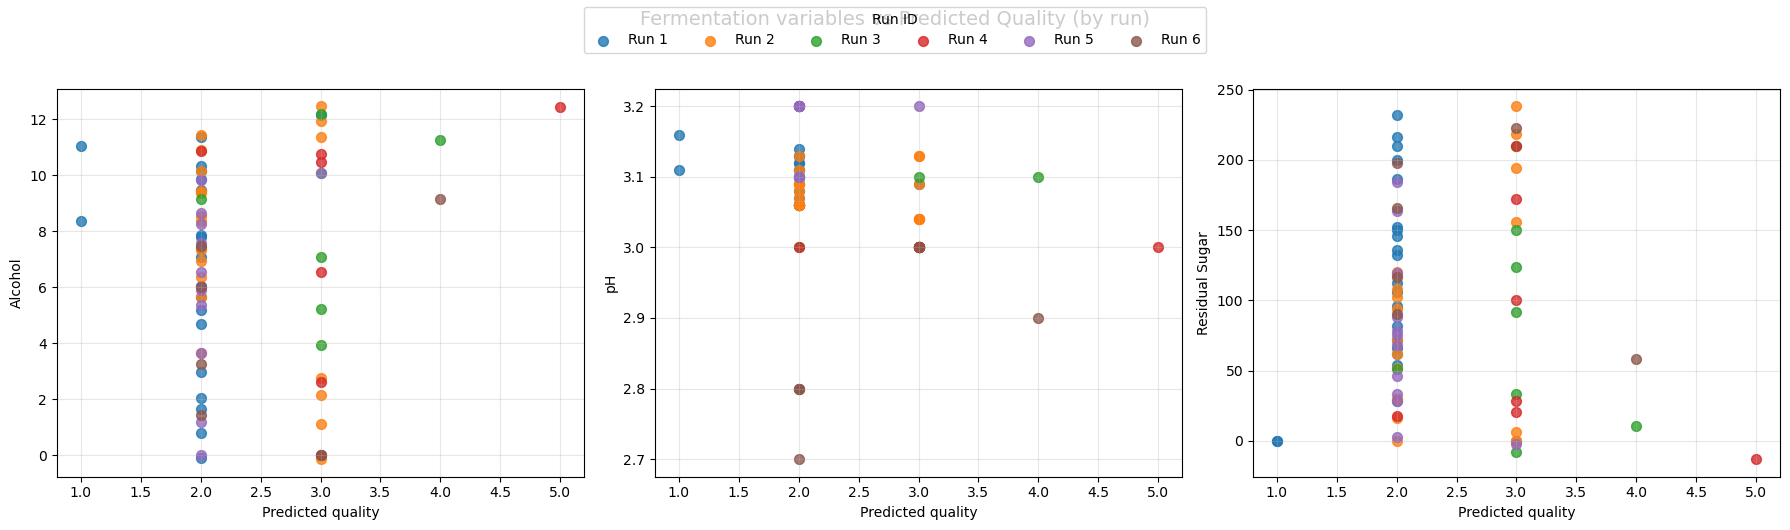

In [95]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

os.makedirs("../fig", exist_ok=True)

# Prepare runs and colormap
runs = ferm_data["run_id"].unique()
cmap = mpl.colormaps["tab10"]

# Create 1x3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# Variables to plot
plots = [
    ("alcohol", "Alcohol"),
    ("pH", "pH"),
    ("residual sugar", "Residual Sugar")
]

for ax, (var, ylabel) in zip(axes, plots):
    for i, run in enumerate(runs):
        subset = ferm_data[ferm_data["run_id"] == run]

        ax.scatter(
            subset["predictionC"],   # X: predicted quality
            subset[var],            # Y: variable
            color=cmap(i),
            label=f"Run {run}",
            alpha=0.8,
            s=50
        )

    ax.set_xlabel("Predicted quality")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# ---- Shared legend (single legend for all subplots)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Run ID",
    loc="upper center",
    ncol=len(runs),
    frameon=True
)

# Main title
fig.suptitle(
    "Fermentation variables vs Predicted Quality (by run)",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.savefig("../fig/quality_vs_fermentation_block.png", dpi=300, bbox_inches="tight")
plt.show()

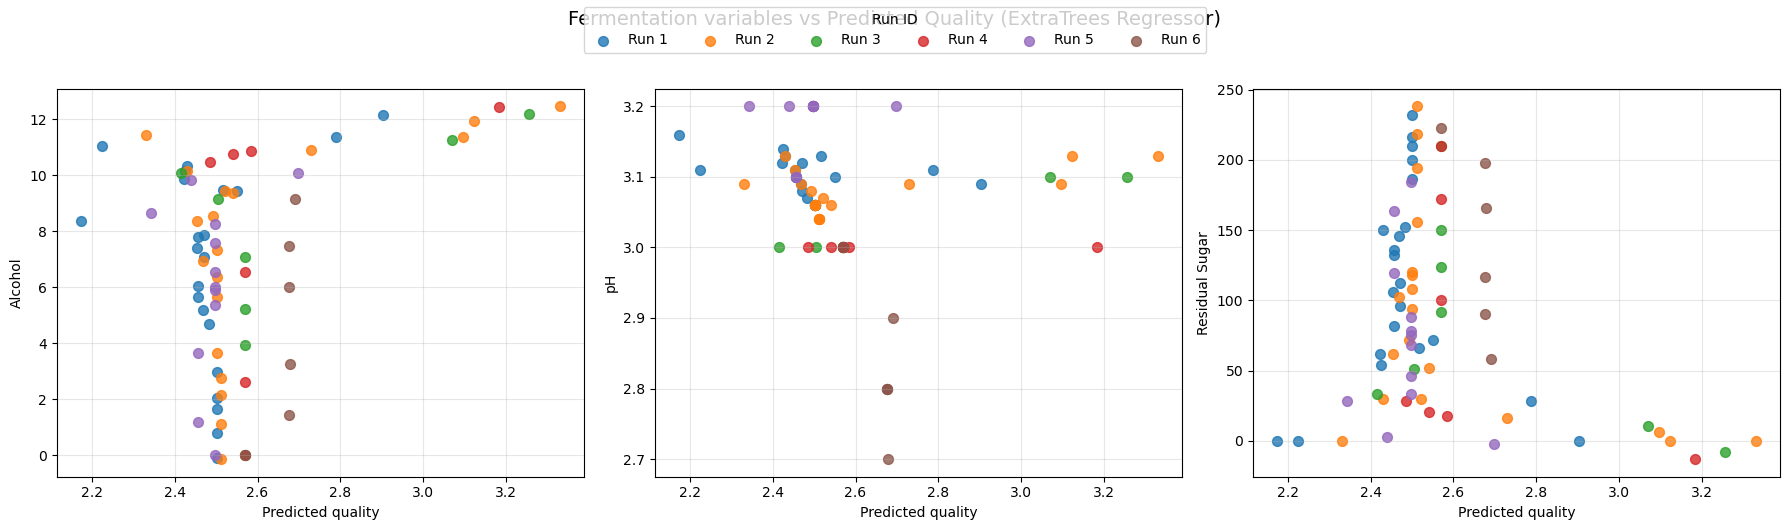

In [96]:
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

os.makedirs("../fig", exist_ok=True)

runs = ferm_data["run_id"].unique()
cmap = mpl.colormaps["tab10"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

plots = [
    ("alcohol", "Alcohol"),
    ("pH", "pH"),
    ("residual sugar", "Residual Sugar")
]

for ax, (var, ylabel) in zip(axes, plots):
    for i, run in enumerate(runs):
        subset = ferm_data[ferm_data["run_id"] == run]

        ax.scatter(
            subset["predictionR"],   # X = predicted quality (continuous)
            subset[var],            # Y = sensor
            color=cmap(i),
            label=f"Run {run}",
            alpha=0.8,
            s=50
        )

    ax.set_xlabel("Predicted quality")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

# Leyenda compartida
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Run ID",
    loc="upper center",
    ncol=len(runs),
    frameon=True
)

fig.suptitle(
    "Fermentation variables vs Predicted Quality (ExtraTrees Regressor)",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.savefig("../fig/quality_vs_fermentation_block_ETC.png", dpi=300, bbox_inches="tight")
plt.show()